
<h1>S&P500 ETF Strategies using Moving Averages</h1>

---



---







**Objective:** 

Through this exploratory data analysis, we aim for two things
*   *To understand and visualise how moving averages help in understanding stock market condition* and 
*   *To see the effectiveness of using moving averages to determine buy and sell timing of S&P500 index*



**Background:** 

The S&P (Standard and Poor's) 500 Index tracks the leading 500 publically traded U.S. stocks across industries. We will use [SPY](https://www.investopedia.com/articles/investing/122215/spy-spdr-sp-500-trust-etf.asp), also known as [SPDR ETF](https://www.investopedia.com/terms/s/spiders.asp), an exchange traded fund that targets 10% of the S&P 500 prices. 

We will focus on investing into SPY for several reasons: 
*   *It is greatly diversified across industries, which minimises our exposure to [idiosyncratic risks](https://www.investopedia.com/terms/i/idiosyncraticrisk.asp)*, 
*   *It generates dividend of ~1.84% as of September 2022  [$^{[\text{1}
]}$](https://www.ssga.com/us/en/institutional/etfs/funds/spdr-sp-500-etf-trust-spy), and* 
*   *It is generally a great place to start investing for someone who do not have much time and expertise for the stock market*.

We will explore the potentials of using moving averages to understand the index and see if we can trade. The idea of a moving average is that it smoothens out the plot and remove noises and fluctuations. This should give us an idea of how the index perform in the long run, depending on the interval in which we average the prices.

<h2>Load Dataset</h2>

---



We will access data remotely from [Stooq](https://stooq.pl/q/?s=%5Espx) using pandas-datareader to get the prices (usually we will use [Yahoo Finance](https://finance.yahoo.com/quote/SPY/history?period1=1262318400&period2=1671422399&interval=1d&frequency=1d&filter=history), but there's recently some issue with fetching data from Yahoo [$^{[\text{2}]}$](https://stackoverflow.com/questions/74832296/typeerror-string-indices-must-be-integers-when-getting-data-of-a-stock-from-y) )


In [ ]:
# Import the relevant libraries
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import datetime
from tqdm import tqdm
%matplotlib inline

In [ ]:
# Specify our target index fund: SPY from stooq between 2010 and 16 Dec 2022
stock_index = 'SPY'
data_source = 'stooq'
start_date = '2010-01-01'
end_date = '2022-12-16'

In [ ]:
# Get the SPY data from the website, sort date in ascending order
data = web.DataReader(stock_index, data_source, start_date, end_date)
data.sort_index(inplace=True)
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,89.8307,90.6358,89.1157,90.5872,1.488007e+08
2010-01-05,90.5436,90.8589,90.2164,90.8273,1.395874e+08
2010-01-06,90.7430,91.1059,90.6636,90.8759,1.452101e+08
2010-01-07,90.7281,91.3816,90.4842,91.2784,1.639960e+08
2010-01-08,91.0235,91.6215,90.8471,91.5818,1.581310e+08


From the data, we can briefly observe that the SPY index has hit the lowest value of \$81.69 and reached a maximum of \$472.23. So technically, if we had put our money in at \$81.69 and sell them at \$472.23, we can gain roughly about $\frac{\$472.23}{\$81.69}-1\approx478\%$ by now.

In [ ]:
display(data.describe().round(2))

,Open,High,Low,Close,Volume
count,3262.00,3262.00,3262.00,3262.00,3.262000e+03
mean,220.16,221.38,218.81,220.18,1.353899e+08
std,105.06,105.75,104.28,105.05,8.931790e+07
min,82.42,82.67,80.84,81.69,2.116804e+07
25%,130.53,130.93,129.96,130.63,7.526220e+07
50%,187.39,188.44,186.59,187.59,1.092494e+08
75%,277.45,278.61,275.69,277.40,1.684321e+08
max,473.72,474.47,470.60,472.23,8.894522e+08


<h2>SPY Price Trends</h2>

---

Overall an upward trend with several dips - most recently in 2018 and 2020 crash - with the recent months of 2022 showing a steady decline.

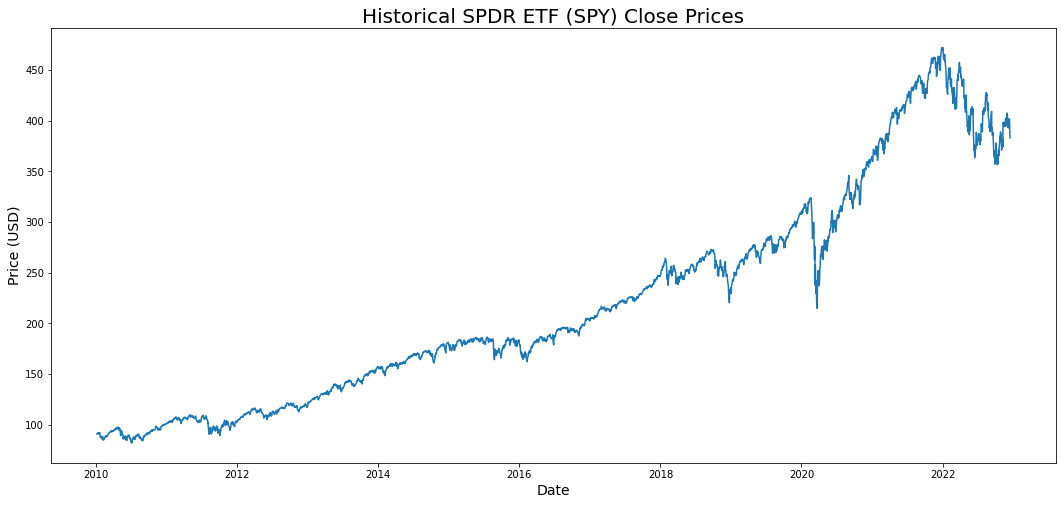

In [ ]:
plt.figure(figsize=(18,8))
plt.plot(data['Close'])
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price (USD)', fontsize=14)
plt.title('Historical SPDR ETF (SPY) Close Prices', fontsize=20)
plt.show()

<h2>Data Processing & Exploration</h2>

---



We will explore two popular types of moving averages:
*   **Simple moving average (SMA)** - equally weighted average price of the index between a specified time interval
*   **Exponential moving average (EMA)** - exponentially weighted average price of the index, giving larger weights to the more recent pricing, between a specified time interval

Generally, the EMA reacts to market reversal relatively quicker than SMA, but technically no one moving average technique is better than the other[$^{[\text{3}
]}$](https://www.investopedia.com/terms/m/movingaverage.asp), so we will explore both.

<h3>Create columns for different moving averages</h3>
<p>We will calculate the different moving averages using commonly used time periods, which are 10D, 20D, 50D, 100D and 200D (days).</p>

In [ ]:
# Set the moving average periods, i.e. 10D, 20D, ...
ma_types = ['exp', 'simple']
periods = [10, 20, 50, 100, 200]

# Create column for each moving average periods
for period in periods:
  column1 = f'simple_ma{period}'
  column2 = f'exp_ma{period}'
  data[column1] = data['Close'].rolling(period).mean()
  data[column2] = data['Close'].ewm(period).mean()

data.dropna(inplace=True)
display(data.head(5))

,Open,High,Low,Close,Volume,simple_ma10,exp_ma10,simple_ma20,exp_ma20,simple_ma50,exp_ma50,simple_ma100,exp_ma100,simple_ma200,exp_ma200
Date,,,,,,,,,,,,,,,
2010-10-18,94.1114,94.8502,93.7743,94.7471,1.769568e+08,93.50726,92.339259,92.340330,90.924380,89.461476,89.685939,88.242516,89.562841,89.755872,89.627673
2010-10-19,93.6910,94.1848,92.7451,93.3112,3.509186e+08,93.56199,92.427617,92.450595,91.038045,89.521230,89.758375,88.290123,89.605762,89.769492,89.656623
2010-10-20,93.4719,94.6816,93.4253,94.2037,2.501790e+08,93.70697,92.589079,92.628045,91.188798,89.608512,89.847165,88.357949,89.658330,89.786374,89.692256
2010-10-21,94.6449,95.1933,93.7109,94.4337,2.770894e+08,93.88545,92.756772,92.853335,91.343325,89.750034,89.938741,88.442820,89.712843,89.804163,89.729306
2010-10-22,94.5587,94.7372,94.3197,94.5963,1.172478e+08,94.02962,92.924002,92.994095,91.498236,89.905160,90.031702,88.506838,89.768505,89.820752,89.767230


<h3>Check baseline returns: hold SPY index from start to end</h3>

In [ ]:
# Calculate returns if we were to invest at the start and hold all the way to the end
baseline_return = data['Close'][-1] / data['Close'][0] - 1
display(baseline_return)

3.045189773618401

Therefore, the baseline return if we put in our money in November 2010 and hold it all the way until December 2022, we would have made 304% returns to the investment.

<h3>Get buy and sell signals across different cross-overs</h3>
<p>The idea of using moving averages is that, when a long-term moving average crosses over a short-term moving average, it indicates a buy-signal. Alternatively, when the short-term moving average crosses over the long-term moving average, it indicates a sell-signal. We will evaluate this strategy, and see how well it compares against just holding a lumpsum value in SPY index.</p>

In [ ]:
# Define function to indicate buy or sell signal
def get_buy_sell_signal(short_indicator, long_indicator, dates, position=True):
  """
  When the long_indicator crosses over the short_indicator, this will be the
  buy signal. Alternatively, when the short_indicator crosses over the 
  long_indicator, this will be the sell signal.
  
  To tell whether it is a buy or a sell signal, we need to compare the
  short_indicator and long_indicator from t-1 and t+1 period, i.e. 
  the algorithm will therefore be:
  - short_indicator[t-1] > long_indicator[t] > short_indicator[t+1] --> sell
  - short_indicator[t-1] < long_indicator[t] < short_indicator[t+1] --> buy

  Note that we will use our position to indicate whether we are in the market
  or out of the market. We can only sell if we are in the market and buy if we
  are out of the market, i.e.
  - position = True --> 

  Output:
  - Returns signals of either {'buy': 1, 'hold': 0, 'sell': -1}
  """
  signals = []

  for t in range(1, len(dates)-1):
    if (short_indicator[dates[t-1]] > long_indicator[dates[t]] 
        and long_indicator[dates[t]] > short_indicator[dates[t+1]]
        and position):
      signal = -1
      position = False
    elif (short_indicator[dates[t-1]] < long_indicator[dates[t]] 
          and long_indicator[dates[t]] < short_indicator[dates[t+1]]
          and not position):
      signal = 1
      position = True
    else:
      signal = 0
    
    signals.append(signal)
  
  return signals

We will categorise the moving averages into short-term MAs and long-term MAs. Short-term MAs will be those 50D and below, while long-term MAs will be those 100D and above, i.e. 100D and 200D. We then pair these short- and long-term MAs to get the cross-over combinations.

In [ ]:
# Get the list of moving average combinations (MA's) to evaluate
short_mas = [f'{ma}_ma{period}' for ma in ma_types for period in periods if period <= 50]
long_mas = [f'{ma}_ma{period}' for ma in ma_types for period in periods if period > 50]

mas_combinations = [(short, long) for short in short_mas for long in long_mas]
print("Total MA's combinations: {:4}".format(len(mas_combinations)))
display(mas_combinations[:5])

Total MA's combinations:   24


[('exp_ma10', 'exp_ma100'),
 ('exp_ma10', 'exp_ma200'),
 ('exp_ma10', 'simple_ma100'),
 ('exp_ma10', 'simple_ma200'),
 ('exp_ma20', 'exp_ma100')]

<h3>Get the buy and sell signals for the different MAs combinations</h3>

In [ ]:
# Get the dates to iterate through the indicators
dates = (data.dropna().index).to_list()

# For each combinations, create one column for the signals
for comb in tqdm(mas_combinations):
  column_name = comb[0] + '__' + comb[1]

  # Set the indicators and dates to check for signals
  short_indicator = data.loc[:, comb[0]].dropna()
  long_indicator = data.loc[:,comb[1]].dropna()

  signals = get_buy_sell_signal(short_indicator, long_indicator, dates)

  data[column_name] = pd.Series(signals, index=dates[1:-1])
  data[column_name] = data[column_name].fillna(0).astype(int)

100%|██████████| 24/24 [00:07<00:00,  3.06it/s]


Assuming we use the close price to check the cross-overs, we would only be able to buy or sell our stocks on the next open market day. Hence, we will use the next day's open price to valuate our index fund.

In [ ]:
# Get the next day's open price for the actual price when buy/sell is executed
data['next_open'] = data['Open'].shift(-1)

<h3>Calculate the returns for each MA combinations</h3>

In [ ]:
# Evaluate each MA cross-over strategy 
starting_value = 100
returns = {}
for comb in tqdm(mas_combinations):
  column_name = comb[0] + '__' + comb[1]
  temp_df = data[data[column_name] != 0][[column_name, 'Close', 'next_open']]

  price = data['Close'].values[0]
  value = starting_value
  position = True
  for index, row in temp_df.iterrows():
    value = value * row['next_open'] / price
    price = row['next_open']
    if row[column_name] == -1:
      position = False
    elif row[column_name] == 1:
      position = True
  
  if position:
    value = data['Close'].values[-1]

  returns[column_name] = {}
  returns[column_name]['value'] = value
  returns[column_name]['returns'] = (value / starting_value) - 1
  returns[column_name]['in_position'] = position

100%|██████████| 24/24 [00:00<00:00, 352.73it/s]


In [ ]:
df_returns = pd.DataFrame(returns).T
df_returns['baseline_comparison'] = df_returns['returns'] - baseline_return
df_returns.sort_values(by='baseline_comparison', ascending=False)

,value,returns,in_position,baseline_comparison
exp_ma10__simple_ma200,463.720789,3.637208,False,0.592018
simple_ma10__simple_ma200,457.158055,3.571581,False,0.526391
exp_ma20__simple_ma200,450.250192,3.502502,False,0.457312
simple_ma50__simple_ma200,448.512936,3.485129,False,0.43994
simple_ma20__simple_ma200,443.405656,3.434057,False,0.388867
simple_ma50__exp_ma100,443.322276,3.433223,False,0.388033
exp_ma10__exp_ma100,436.676162,3.366762,False,0.321572
exp_ma20__exp_ma100,431.264915,3.312649,False,0.267459
simple_ma10__exp_ma100,423.87577,3.238758,False,0.193568
exp_ma20__exp_ma200,420.738999,3.20739,False,0.1622


In [ ]:
df_returns.mean()

value                  415.202649
returns                  3.152026
in_position              0.250000
baseline_comparison      0.106837
dtype: float64

On average, the MA crossover strategy gives ~10.7% better results than the baseline return.

<h2>Data Visualisation and Analysis</h2>

---



<h3>Visualising the difference in returns against baseline</h3>

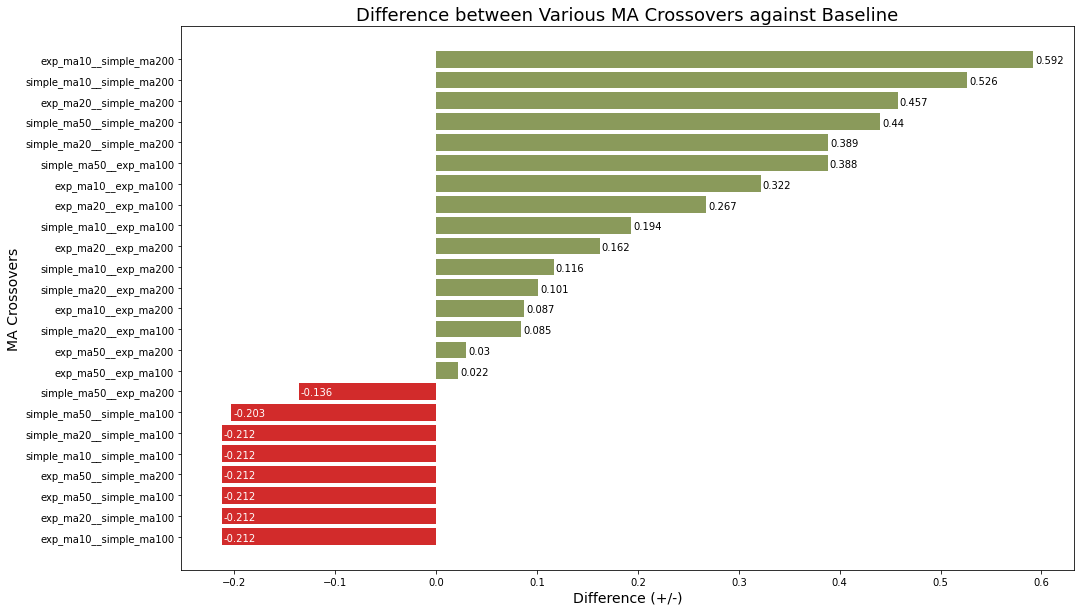

In [ ]:
positive_df = df_returns[df_returns['baseline_comparison'] > 0].sort_values(by='baseline_comparison', ascending=True)
negative_df = df_returns[df_returns['baseline_comparison'] < 0].sort_values(by='baseline_comparison', ascending=True)

plt.figure(figsize=(16, 10))
plt.barh(negative_df.index, negative_df['baseline_comparison'], color='#D22B2B')
plt.barh(positive_df.index, positive_df['baseline_comparison'], color='#8A9A5B')

for i, r in df_returns.iterrows():
  if r['baseline_comparison'] < 0:
    font_colour = 'white'
  else:
    font_colour = 'black'
  plt.annotate(
      round(r['baseline_comparison'], 3), (r['baseline_comparison'], i)
      , xytext = (2, -4), textcoords='offset points', color = font_colour
      )

plt.xlabel('Difference (+/-)', fontsize=14)
plt.ylabel('MA Crossovers', fontsize=14)
plt.title('Difference between Various MA Crossovers against Baseline', fontsize=18)

plt.show()

There are 15 MA crossover combinations which yield better returns compared to purely holding the stock since the start and 9 which give worse returns. The highest gain is obtained from using the MAs combination of 10D Exponential MA against 200D Simple MA, **reaching 59.2% higher returns than the baseline** (purely holding the index fund).

Four (4) out of the top five (5) seems to be those MAs with very short periods (10D and 20D) against Simple MAs of 200D period. Furthermore, it seems to be the case that the short-term Exponential MAs for these groups, works better than the Simple MAs counterparts (10D and 20D) when crossing over against Simple MAs of 200D period. This might suggests that to maximise the gains from the MA crossover strategy, we may want to use **very responsive short-term MAs against longer-term MAs**.

<h3>Visualising the buy-and-sell MA crossover strategy</h3>
<p>We use the top MA combination in to visualise the actual performance when buying and selling following the strategy.</p>

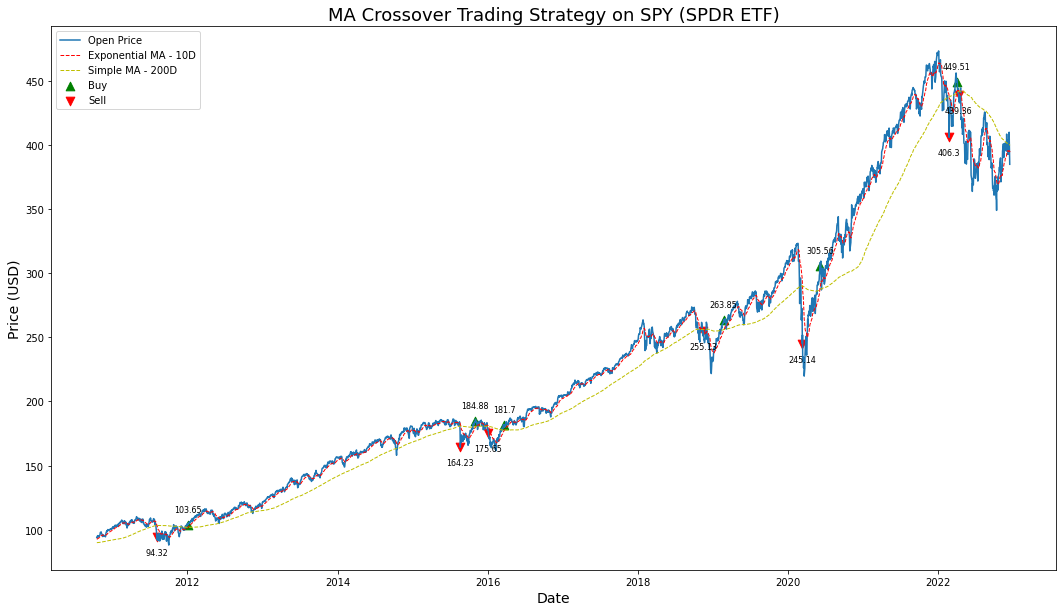

In [ ]:
df_signals = data[data['exp_ma10__simple_ma200'] != 0][['exp_ma10__simple_ma200', 'Close', 'next_open']]
buy_signals = df_signals[df_signals['exp_ma10__simple_ma200'] == 1]
sell_signals = df_signals[df_signals['exp_ma10__simple_ma200'] == -1]

plt.figure(figsize=(18,10))
plt.plot(data['next_open'])
plt.plot(data['exp_ma10'], 'r--', linewidth=1)
plt.plot(data['simple_ma200'], 'y--', linewidth=1)

plt.scatter(buy_signals.index, buy_signals['next_open'], marker='^', c='g', s=75)
plt.scatter(sell_signals.index, sell_signals['next_open'], marker='v', c='r', s=75)

for i in df_signals.index:
  d = i.strftime('%Y-%m-%d')
  if df_signals.loc[d, 'exp_ma10__simple_ma200'] == 1:
    plt.annotate(
        round(df_signals.loc[d, 'next_open'], 2)
        , (i, df_signals.loc[d, 'next_open'])
        , textcoords='offset points', xytext=(0,20)
        , fontsize=8, ha='center', va='top')
  else:
    plt.annotate(
        round(df_signals.loc[d, 'next_open'], 2)
        , (i, df_signals.loc[d, 'next_open'])
        , textcoords='offset points', xytext=(0,-20)
        , fontsize=8, ha='center', va='bottom')

plt.xlabel('Date', fontsize=14)
plt.ylabel('Price (USD)', fontsize=14)
plt.title('MA Crossover Trading Strategy on SPY (SPDR ETF)', fontsize=18)

plt.legend(['Open Price', 'Exponential MA - 10D', 'Simple MA - 200D', 'Buy', 'Sell'])
plt.show()

<h2>Further Analysis</h2>


---


The above analysis seems to show that the MA crossover strategy wins against the baseline of simply holding the stock all the way. However, if we were to try to understand a bit deeper, that is not the case. The above "win" is attainable when taking the specific snapshot of the SPY prices on that period. If we instead perform this same anaylsis across different periods, let's say the end date is moved back to the end of 2021 we would actually be losing money as we entered the market too late.


In [ ]:
#@title Replicating the steps done in the previous analysis on other time period

# 1. retreive the stock index prices data
def get_prices_data(stock=stock_index, source=data_source, start=start_date, end=end_date):
  df = web.DataReader(stock, source, start, end)
  df = df.sort_index()
  df['next_open'] = df['Open'].shift(-1)
  return df

# 2. get different columns of MAs
def insert_mas_into(df, periods=periods, col='Close'):
  # returns a copy of the input dataframe with exp and simple MAs
  df_copy = df.copy()

  for period in periods:
    col1 = f'simple_ma{period}'
    col2 = f'exp_ma{period}'
    df_copy[col1] = df_copy[col].rolling(period).mean()
    df_copy[col2] = df_copy[col].ewm(period).mean()

  df_copy.dropna(inplace=True)
  return df_copy

# 3. generate the buy and sell signals from different MA combinations
def mass_generate_signals_from(df, combs=mas_combinations):
  # returns a copy of the input dataframe with buy and sell signals of each MA combination
  df_copy = df.copy()
  dates = (df_copy.dropna().index).to_list()

  for comb in combs:
    col = comb[0] + '__' + comb[1]
    short_ind = data.loc[:, comb[0]].dropna()
    long_ind = data.loc[:, comb[1]].dropna()

    signals = get_buy_sell_signal(short_ind, long_ind, dates)

    df_copy[col] = pd.Series(signals, index=dates[1:-1])
    df_copy[col] = df_copy[col].fillna(0).astype(int)
  
  return df_copy

# 4. generate the buy and sell signals from different MA combinations
def get_returns_dataframe(df, combs=mas_combinations, starting_value=100):
  # returns a new dataframe that contains the returns for each MA combination
  ret = {}
  for comb in combs:
    col = comb[0] + '__' + comb[1]
    df_copy = df[df[col] != 0][[col, 'Close', 'next_open']].copy()

    price = df['Close'].values[0]
    value = starting_value
    position = True
    for index, row in df_copy.iterrows():
      value = value * row['next_open'] / price
      price = row['next_open']
      if row[col] == -1:
        position = False
      elif row[col] == 1:
        position = True
    
    if position:
      value = df['Close'].values[-1]

    ret[col] = {}
    ret[col]['value'] = value
    ret[col]['returns'] = (value / starting_value) - 1
    ret[col]['in_position'] = position
  
  df_r = pd.DataFrame(ret).T
  bs_ret = df['Close'][-1] / df['Close'][0] - 1
  df_r['baseline_comparison'] = df_r['returns'] - bs_ret
  df_r.sort_values(by='baseline_comparison', ascending=False)

  return df_r

In [ ]:
# Replicating the previous analysis using different end date
# end_date = (datetime.date.today()).strftime('%Y-%m-%d')
data2 = mass_generate_signals_from(
          insert_mas_into(
              get_prices_data(end='2021-12-01')
        ))

dates2 = (data2.dropna().index).to_list()
baseline_return2 = data2['Close'][-1] / data2['Close'][0] - 1
df_returns2 = get_returns_dataframe(data2)

As can be seen, all the MA combinations produce **a poorer result as compared to the baseline by 24.87%** when calculated up to December 2021. This is likely because we are entering the market relatively lagged when relying on MAs as **MAs are less responsive**. As a result, when the SPY index is bullish, we will perform worse. On the other hand, when the SPY index is declining, we may seem to perform better off just because we pulled out from the declining index. In that, we would actually be better off if we pulled out any other time, ignoring the MA crossover, since there are better closing prices available before or after the crossover at $406.3.

In [ ]:
display(df_returns2.mean())
display(df_returns2.sort_values(by='baseline_comparison').head(3))
display(df_returns2.sort_values(by='baseline_comparison').tail(3))

value                  448.752000
returns                  3.487520
in_position              1.000000
baseline_comparison     -0.248794
dtype: float64

,value,returns,in_position,baseline_comparison
exp_ma10__exp_ma100,448.752,3.48752,True,-0.248794
simple_ma50__exp_ma200,448.752,3.48752,True,-0.248794
simple_ma50__exp_ma100,448.752,3.48752,True,-0.248794


,value,returns,in_position,baseline_comparison
exp_ma10__exp_ma200,448.752,3.48752,True,-0.248794
simple_ma50__simple_ma100,448.752,3.48752,True,-0.248794
simple_ma50__simple_ma200,448.752,3.48752,True,-0.248794


<h3>Improvements on buy-sell timings based on visual estimations</h3>

In [ ]:
def ptime(date):
  # Parse string into date
  return datetime.datetime.strptime(date, '%Y-%m-%d')

def avgp(date_tuple):
  # Get the average closing price across the given date period
  # date_tuple: a tuple of start and end date of a period
  start = date_tuple[0]
  end = datetime.datetime.strftime(ptime(date_tuple[1]) + datetime.timedelta(days=1), '%Y-%m-%d')
  avg_price = data.loc[start: end, 'Close'].mean()
  return avg_price

In [ ]:
# Select the time periods to perform buy or sell on the SPY
# Dates are selected based on visual judgement and hardcoded
sell_periods = [
     ('2011-07-05', '2011-07-24')
     , ('2015-07-16', '2015-08-08')
     , ('2018-09-01', '2018-09-30')
     , ('2020-01-16', '2020-02-16')
     , ('2021-11-14', '2022-01-14')
    ]

buy_periods = [
     ('2011-08-10', '2011-09-24')
     , ('2015-08-28', '2015-09-21')
     , ('2018-12-20', '2019-01-10')
     , ('2020-03-16', '2020-04-10')
    ]

In [ ]:
# initialise the starting value and position
starting_value = 100
value = starting_value
prev_value = data.loc[data.index[0], 'Close']
hold = True
i, j = 0, 0

# During sell, the stock amount is multiplied by ratio of new value against prev value 
# During buy, the stock amount is multiplied by ratio of prev value against new value
# Only buy when not holding, and only sell when holding
# Assume that a sell is always followed by a buy in the next period
while j < len(buy_periods) and i < len(sell_periods):
  if hold == True:
    value = value * avgp(sell_periods[i]) / prev_value
    prev_value = avgp(sell_periods[i])
    hold = False
    i += 1
  else:
    value = value * prev_value / avgp(buy_periods[j])
    prev_value = avgp(buy_periods[j])
    hold = True
    j += 1

returns = (value - starting_value)/starting_value
returns_vs_baseline = returns - baseline_return
returns_vs_ma_co = returns_vs_baseline - df_returns.loc['exp_ma10__simple_ma200', 'baseline_comparison']

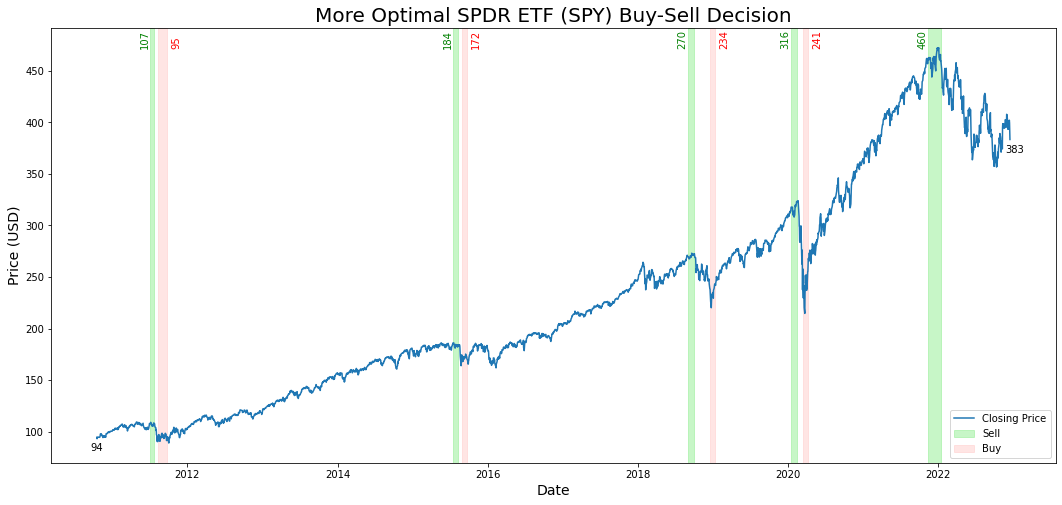

In [ ]:
plt.figure(figsize=(18,8))
line = plt.plot(data['Close'])

for sp in sell_periods:
  start, end = sp
  sspan = plt.axvspan(ptime(start), ptime(end), alpha = 0.5, color = '#90ee90')
  plt.text(
      x = ptime(start) + datetime.timedelta(-50), y =  473
      , s = str(int(avgp(sp)))
      , rotation = 90
      , fontsize = 10
      , color = 'green'
    )

for bp in buy_periods:
  start, end = bp
  bspan = plt.axvspan(ptime(start), ptime(end), alpha = 0.5, color = '#FFCCCB')
  plt.text(
      x = ptime(end) + datetime.timedelta(20), y =  473
      , s = str(int(avgp(bp)))
      , rotation = 90
      , fontsize = 10
      , color = 'red'
    )

plt.annotate(int(data.loc[data.index[0], 'Close'])
             , (data.index[0], data.loc[data.index[0], 'Close'])
             , textcoords='offset points', xytext=(0, -15)
             , fontsize=10, ha='center', va='bottom')

plt.annotate(int(data.loc[data.index[-1], 'Close'])
             , (data.index[-1], data.loc[data.index[-1], 'Close'])
             , textcoords='offset points', xytext=(5, -15)
             , fontsize=10, ha='center', va='bottom')

plt.xlabel('Date', fontsize=14)
plt.ylabel('Price (USD)', fontsize=14)
plt.title('More Optimal SPDR ETF (SPY) Buy-Sell Decision', fontsize=20)
plt.legend([line[0],sspan,bspan], ['Closing Price', 'Sell', 'Buy'], loc='lower right')
plt.show()

Based on the buy and sell timings in the illustration above, we obtain **a much better returns of ~743%**, more than 400% higher than baseline and 379% higher than the MA crossover. Of course there are much better decisions and buy-sell timings available to maximise the returns, but with simple visualisation and eye-balling we are able to come up with double the returns. Therefore, in theory, there are still room to improve the returns and further explorations into other strategies are required.

In [ ]:
print(f'Starting value: {starting_value:#.2f}')
print(f'Final value: {value:#.2f}')
print(f'Returns to investment: {returns:#.2f}x')
print(f'Returns compared to baseline: {returns_vs_baseline:#.2f}')
print(f'Returns compared to MAs Crossover: {returns_vs_ma_co:#.2f}')

Starting value: 100.00
Final value: 843.14
Returns to investment: 7.43x
Returns compared to baseline: 4.39
Returns compared to MAs Crossover: 3.79


<h2>Conclusion</h2>

---

The MA crossover strategy seems to work well, especially when using very short-term MAs against 200D simple MA. Upon further analysis, however, we notice that is not the case as we vary the period of interest. The MA crossover flaw is that MAs are lagged, resulting in late response to enter or exit the market.

Nevertheless, we have seen the importance of MAs when determining the market trends and sentiments. The short and long-term MAs enable us to objectively assess the market trends and could still be used as indicators to notify us before our market entry or exit turns even later.

Upon further visualisation, we can also observe that the buy and sell decisions could be better timed for a much improved yield on the returns. Other strategies need to be explored, researched and analysed.

<h2>Reflection</h2>

---

It is important to adopt a more sceptical view on one's own analysis to avoid our own bias, thinking that the analysis is a job well done and we have achieved the answer we needed. Revisiting the analysis and viewing the problem from multiple angles help to give a truer, more objective analysis.

<h2>References</h2>

---



[1] State Street Global Advisors (2022) *Fact Sheet:SPDR® S&P 500® ETF Trust* https://www.ssga.com/library-content/products/factsheets/etfs/us/factsheet-us-en-spy.pdf [Accessed 17th December 2022]

[2] Buck, D. (2022) *\"TypeError: string indices must be integers\" when getting data of a stock from Yahoo Finance using Pandas Datareader.* Stackoverflow. 17th December. https://stackoverflow.com/questions/74832296/typeerror-string-indices-must-be-integers-when-getting-data-of-a-stock-from-y [Accessed 17th December 2022]

[3] Fernando, J. (2022) *Moving Average (MA): Purpose, Uses, Formula, and Examples.* https://www.investopedia.com/terms/m/movingaverage.asp [Accessed 18th December 2022]